### Лабораторная работа №7 по ТМО

#### Ансамбли моделей машинного обучения. Часть 2.

Цель лабораторной работы: изучение ансамблей моделей машинного обучения.

Задание:

1. Выберите набор данных (датасет) для решения задачи классификации или регресии.

2. В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.

3. С использованием метода train_test_split разделите выборку на обучающую и тестовую.

4. Обучите следующие ансамблевые модели:

    + одну из моделей группы стекинга.
    + модель многослойного персептрона. По желанию, вместо библиотеки scikit-learn возможно использование библиотек TensorFlow, PyTorch или других аналогичных библиотек.
    + (дополнительно) двумя методами на выбор из семейства МГУА (один из линейных методов COMBI / MULTI + один из нелинейных методов MIA / RIA) с использованием библиотеки gmdh.
    + В настоящее время библиотека МГУА не позволяет решать задачу классификации !!!

5. Оцените качество моделей с помощью одной из подходящих для задачи метрик. Сравните качество полученных моделей.

6. В телегамм-канале потока ИУ5 в теме ТМО_МГУА напишите обратную связь по использованию библиотеки gmdh:

    + обнаруженные баги с приложением скриншотов ошибок, за каждый найденный баг +1 балл на экзамене;
    + опечатки в документации или учебном пособии МГУА;
    + возникшие вопросы или трудности при установке и использовании библиотеки;
    + любая другая информация (критика, предложения по улучшению и тд).



В качестве исходного датасета возьму __California Housing Prices Dataset__ - https://www.kaggle.com/datasets/nalisha/california-housing-prices-dataset-clean-and-ml (такой, же, как и в первой части этой лабораторной работы)

Этот набор данных содержит подробную информацию о жилых кварталах Калифорнии, включая географическое расположение, статистику населения и уровень доходов. 

Каждая строка представляет собой конкретный район, а столбцы описывают различные характеристики, такие как медианный доход, количество комнат, численность населения и близость к океану.

В этом датасете следующие столбцы:

+ **longitude** - Географические координаты (положение восток-запад)
+ **latitude** - Географические координаты (положение с севера на юг)
+ **housing_median_age** - Средний возраст домов в этом районе
+ **total_rooms** - Общее количество комнат во всех домах
+ **total_bedrooms** - Общее количество спален
+ **population** - Общая численность населения в этом районе
+ **households** - Количество домохозяйств (семей)
+ **median_income** - Медианный доход жителей
+ **median_house_value** - Медианная цена на жилье (целевая переменная)
+ **ocean_proximity** - Расстояние от океана (категориальный признак)

Первым делом загрузим датасет и убедимся, что нет пропусков (при необходимости удалим пропуски), затем посмотрим на список столбцов и их типы.

In [10]:
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
houses_origin = pd.read_csv("./housing.csv")

houses_origin.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [3]:
print('Всего строк: {}'.format(houses_origin.shape[0]))

print(f"\nВсего пропусков: {houses_origin.isnull().sum().sum()}")

for i in list(houses_origin.columns):
    print(i + "\t" + str(houses_origin[i].isnull().sum()) + "\t" + str(round(houses_origin[i].isnull().mean()*100, 2)) + "%")

Всего строк: 20640

Всего пропусков: 207
longitude	0	0.0%
latitude	0	0.0%
housing_median_age	0	0.0%
total_rooms	0	0.0%
total_bedrooms	207	1.0%
population	0	0.0%
households	0	0.0%
median_income	0	0.0%
median_house_value	0	0.0%
ocean_proximity	0	0.0%


Видим 207 пропусков в наборе - в столбце "число спален" недобор. Ввиду малого числа пропусков (всего 1% - просто удалю соответствующие строки)

In [4]:
houses_cleaned = houses_origin.dropna()

print('Всего строк: {}'.format(houses_cleaned.shape[0]))

for i in list(houses_cleaned.columns):
    print(i + "\t" + str(houses_cleaned[i].isnull().sum()) + "\t" + str(round(houses_cleaned[i].isnull().mean()*100, 2)) + "%")

Всего строк: 20433
longitude	0	0.0%
latitude	0	0.0%
housing_median_age	0	0.0%
total_rooms	0	0.0%
total_bedrooms	0	0.0%
population	0	0.0%
households	0	0.0%
median_income	0	0.0%
median_house_value	0	0.0%
ocean_proximity	0	0.0%


Теперь всё в порядке с пропусками

In [5]:
print("Список колонок с типами данных: ")
houses_cleaned.dtypes

Список колонок с типами данных: 


longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

В целом всё замечательно - данные однотипные, но ocean_proximity как категориальный признак надо бы перевести в числовой вид (чем меньше значение, тем ближе к океану)

In [6]:
# Смотрим уникальные значения и их частоту
print("Уникальные значения ocean_proximity:")
print(houses_cleaned['ocean_proximity'].unique())
print("\nРаспределение по категориям:")
print(houses_cleaned['ocean_proximity'].value_counts())

Уникальные значения ocean_proximity:
<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

Распределение по категориям:
ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64


По найденной информации:

<1H OCEAN - Менее 1 часа пути до океана

INLAND - Внутренние районы, далеко от побережья

NEAR OCEAN - Рядом с океаном, но не на берегу

NEAR BAY - Рядом с заливом (Сан-Франциско, Лос-Анджелес)

ISLAND - Островные территории (очень редко)

Ввиду малого числа, island просто уберём, а остальный закодируем порядково

In [7]:
houses_categs = houses_cleaned[houses_cleaned['ocean_proximity'] != 'ISLAND']

# Задаём порядок: от "дальше от воды" к "ближе к воде/заливу" (значения приняты гипотетические)
order_mapping = {
    'INLAND': 0,           # в глубине материка
    'NEAR OCEAN': 1,       # рядом с океаном
    '<1H OCEAN': 2,        # в пределах часа от океана
    'NEAR BAY': 3          # у залива (часто самые дорогие районы)
}

# Применяем маппинг
houses_categs['ocean_proximity_ord'] = houses_categs['ocean_proximity'].map(order_mapping)

houses_categs = houses_categs.drop(columns=['ocean_proximity'])

print("Уникальные значения ocean_proximity:")
print(houses_categs['ocean_proximity_ord'].unique())

print("Список колонок с типами данных: ")
houses_categs.dtypes

Уникальные значения ocean_proximity:
[3 2 0 1]
Список колонок с типами данных: 


longitude              float64
latitude               float64
housing_median_age     float64
total_rooms            float64
total_bedrooms         float64
population             float64
households             float64
median_income          float64
median_house_value     float64
ocean_proximity_ord      int64
dtype: object

Данные обработаны. Дальше делим на обучающую и тестовую выборки, после чего обучим модели

In [8]:
# Удаляем исходный текстовый столбец, чтобы модели не сломались
X = houses_categs.drop(['median_house_value'], axis=1)
y = houses_categs['median_house_value']

from sklearn.model_selection import train_test_split

# X - признаки (уже с закодированным ocean_proximity)
# y - целевая переменная (median_house_value)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.25,      # 25% на тест, 75% на обучение
    random_state=42,     # фиксация для воспроизводимости
    shuffle=True
)
print(f"Train: {X_train.shape[0]} строк | Test: {X_test.shape[0]} строк")

Train: 15321 строк | Test: 5107 строк


In [14]:
# MLP и Stacking требуют масштабирования признаков
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

results = []

# 4.1 Steacking (базовые модели + финальный мета-классификатор/регрессор)
print("Обучаем Stacking...")
stack_model = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingRegressor(n_estimators=50, random_state=42))
    ],
    final_estimator=Ridge(), # линейная модель "склеивает" прогнозы базовых
    cv=5,
    n_jobs=-1
)
t0 = time.time()
stack_model.fit(X_train_sc, y_train)
y_pred_stack = stack_model.predict(X_test_sc)
t_stack = round(time.time() - t0, 3)


# 4.3 GMDH 
# gmdh_models = {}
# try:
#     from gmdh import GMDHRegressor
#     print("▶ Обучаем GMDH (линейный COMBI)...")
#     gmdh_lin = GMDHRegressor(selection_criterion='COMBI', external_criterion='RMSE')
#     t0 = time.time()
#     gmdh_lin.fit(X_train_sc, y_train)
#     y_pred_gmdh_lin = gmdh_lin.predict(X_test_sc)
#     t_lin = round(time.time() - t0, 3)
#     gmdh_models['GMDH (COMBI)'] = (y_pred_gmdh_lin, t_lin)

#     print("▶ Обучаем GMDH (нелинейный MIA)...")
#     gmdh_nl = GMDHRegressor(selection_criterion='MIA', external_criterion='RMSE')
#     t0 = time.time()
#     gmdh_nl.fit(X_train_sc, y_train)
#     y_pred_gmdh_nl = gmdh_nl.predict(X_test_sc)
#     t_nl = round(time.time() - t0, 3)
#     gmdh_models['GMDH (MIA)'] = (y_pred_gmdh_nl, t_nl)
# except ImportError:
#     print("   Библиотека gmdh не установлена. Пропускаем опциональный пункт.")

Обучаем Stacking...


Обучаем MLP...


/mnt/WORK/BM57U/machine_learning/lab_7_tmo/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


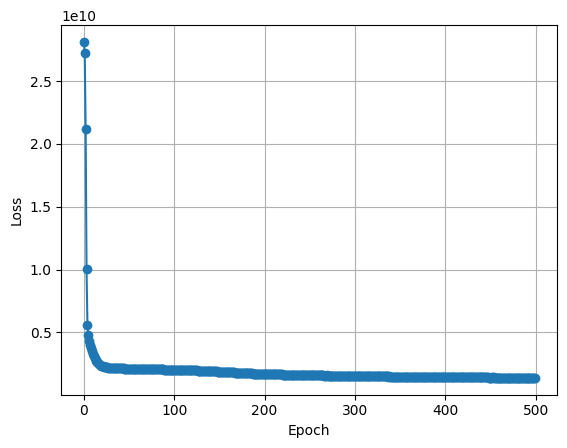

In [19]:
# 4.2 MLP (Многослойный персептрон)
print("Обучаем MLP...")
mlp_model = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    # alpha=0.001, 
    random_state=42,
    # early_stopping=True,
    validation_fraction=0.1
)
t0 = time.time()
mlp_model.fit(X_train_sc, y_train)
y_pred_mlp = mlp_model.predict(X_test_sc)
t_mlp = round(time.time() - t0, 3)

plt.plot(mlp_model.loss_curve_, marker='o')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid()
plt.show()

Пункт про методы МГУА (библиотека gmdh) не был выполнен в связи с техническими ограничениями: пакет требует компиляции C++ расширений с зависимостью на системные библиотеки Boost, которые отсутствуют в среде выполнения.  В итоге библиотка не была установлена, а попытки добиться компиляции пакета после установки boost ни к чему не привели.

In [20]:
# 5. Оценка и сравнение
def calc_metrics(y_true, y_pred):
    return {
        "RMSE ($)": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "MAE ($)": round(mean_absolute_error(y_true, y_pred), 2),
        "R^2": round(r2_score(y_true, y_pred), 4)
    }

results.append({"Модель": "Stacking"} | calc_metrics(y_test, y_pred_stack) | {"Время (с)": t_stack})
results.append({"Модель": "MLP"} | calc_metrics(y_test, y_pred_mlp) | {"Время (с)": t_mlp})

# if gmdh_models:
#     for name, (pred, t) in gmdh_models.items():
#         results.append({"Модель": name} | calc_metrics(y_test, pred) | {"Время (с)": t})

df_res = pd.DataFrame(results)
print("\nИтоговая таблица качества на тестовой выборке:")
display(df_res) 


Итоговая таблица качества на тестовой выборке:


,Модель,RMSE ($),MAE ($),R^2,Время (с)
0,Stacking,48834.36,31714.28,0.8192,6.281
1,MLP,55760.71,37948.62,0.7642,89.767
2,Stacking,48834.36,31714.28,0.8192,6.281
3,MLP,54397.97,36629.70,0.7756,124.771


В итоге модель стакинга проявила себя лучше и по времени, и по R^2.

Сперва я попробовал MLP с 128 и 64 cлоями нейронов, что дало  0.68 R^2 ошибки. Добавление ещё одного слоя на 256 нейронов, а также ослабление L2-регуляризации до 0.001 дало результат в 0.7642 на тестовой выборке. А early_stopping=True спасает от переобучения.

Однако, когда я убрал ограничение по эпохам и оставил alpha по умолчанию (0.0001) то результаты стали ещё лучше! Переобучения не обнаружено!

**Почему MLP уступил?**  
Многослойный персептрон показал худшее качество (R^2 ~= 0.68 и 0.76 соответственно), что типично для табличных данных: нейросети требуют тщательной настройки архитектуры, нормализации и часто проигрывают ансамблям деревьев на задачах с умеренным объёмом выборки.  
  
**Почему Stacking сработал лучше?**  
Мета-обучение позволило объединить прогнозы разнородных моделей (случайный лес ловит нелинейные взаимодействия, градиентный бустинг уточняет остаточные ошибки), а линейный финальный регуляризатор (`Ridge`) предотвратил переобучение на шумах.

In [ ]:
print("Коэффициенты мета-модели (Ridge):")
print(stack_model.final_estimator_.coef_)

Анализ коэффициентов мета-модели показал, что Ridge присвоил вес ~0.99 прогнозам случайного леса и ~0.03 — градиентному бустингу. Это свидетельствует о том, что на данном наборе данных прогнозы случайного леса были более надёжными и менее зашумлёнными на out-of-fold выборках. Стекинг автоматически выявил эту закономерность и адаптировал веса, что демонстрирует его главное преимущество: способность комбинировать модели не «вслепую», а на основе их реальной обобщающей способности.